# Experimenting under Stochastic Congestion — Demo Notebook

This notebook demonstrates the `congestion_experiments` package, which implements the estimators from:

> Li, Johari, Kuang, and Wager, *Experimenting under Stochastic Congestion*, Management Science.

## Contents
1. **Setup & model description**
2. **Usage examples** — how to simulate experiments and run estimators
3. **Simulation study** — comparing estimators across designs and settings

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

# Make sure the package is importable
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from congestion_experiments import (
    simulate_interval_switchback,
    simulate_regenerative_switchback,
    simulate_user_level,
    model_free_estimator,
    idle_time_estimator,
    wde_estimator,
    wde_estimator_user_level,
    wde_estimator_nonstationary,
    wde_estimator_nonstationary_user_level,
)
from congestion_experiments.simulator import compute_summary_stats
from congestion_experiments.variance import (
    variance_model_free,
    variance_idle_time,
    variance_wde,
    confidence_interval,
    compute_all_variances,
)

plt.rcParams.update({'figure.figsize': (10, 4), 'font.size': 11})
print('Setup complete.')

Setup complete.


---
## 1. Model Description

We consider a single-server queue with:
- Poisson arrivals at state-dependent rate $\lambda_k(p)$ when the queue length is $k$ and price is $p$
- Exponential service at rate $\mu$
- The goal is to estimate the policy gradient $V'(p)$ — how the long-run processing rate changes with price

### Zero-deflated M/M/1

The primary illustrative example is a **zero-deflated M/M/1** queue where the arrival rate at state $k=0$ is *elevated* compared to states $k \ge 1$:
$$\lambda_k(p) = \begin{cases} \lambda_0 \cdot (2 - p) & k = 0 \\ 0.5 \cdot (2 - p) & 1 \le k < K \\ 0 & k \ge K \end{cases}$$
with $\lambda_0 = 2$, so the queue is "deflated" at zero (spends less time idle than a standard M/M/1).

### Defining arrival rate functions

The package expects `lambda_k(k, p)` for stationary settings and `lambda_k(k, p, t)` for non-stationary.

In [2]:
# === Example 1: Zero-deflated M/M/1 queue ===
# Arrival rate at state k=0 is *higher* than at other states (zero-deflated).
# lambda_vec = c(lambda_0, lambda, lambda, ..., lambda) * (2 - p)
# With lambda_0 = 2, lambda = 0.5, p = 1, K = 15:
#   lambda_k(p) = (2 - p) * lambda_0   for k = 0
#   lambda_k(p) = (2 - p) * 0.5        for 1 <= k < K
#   lambda_k(p) = 0                     for k >= K

LAMBDA_0 = 2.0   # zero-deflated: elevated arrivals when idle
LAMBDA_BASE = 0.5
K_MAX = 15

def lambda_zi_mm1(k, p):
    """Zero-deflated M/M/1 queue: elevated arrival rate at state 0."""
    price_attractive = max(0.0, 2.0 - p)
    if k >= K_MAX:
        return 0.0
    if k == 0:
        return LAMBDA_0 * price_attractive
    return LAMBDA_BASE * price_attractive

# === Example 2: Power-law joining probability ===
def lambda_power_law(k, p, K_max=15, alpha=0.4):
    """Arrival rate with power-law decay: lambda*(k+1)^(-alpha)."""
    if k >= K_max:
        return 0.0
    return max(0.0, (2.0 - p) * 2 * (k + 1) ** (-alpha))

mu = 1.0
p = 1.0    # reference price
zeta = 0.05 # price perturbation

# === True V'(p) via numerical differentiation ===
import numpy as np

def find_pi_equi(lambda_k_func, mu, p, K):
    """Compute exact stationary distribution of the birth-death chain."""
    lam = [lambda_k_func(k, p) for k in range(K + 1)]
    pi = np.ones(K + 1)
    for k in range(1, K + 1):
        pi[k] = pi[k - 1] * lam[k - 1] / mu
    pi /= pi.sum()
    return pi

def find_lambda_bar(lambda_k_func, mu, p, K):
    """Compute throughput = sum_k lambda_k * pi_k."""
    lam = np.array([lambda_k_func(k, p) for k in range(K + 1)])
    pi = find_pi_equi(lambda_k_func, mu, p, K)
    return np.sum(lam * pi)

eps = 1e-4
lambda_bar_plus = find_lambda_bar(lambda_zi_mm1, mu, p + eps, K_MAX)
lambda_bar_minus = find_lambda_bar(lambda_zi_mm1, mu, p - eps, K_MAX)
true_Vprime_zi = (lambda_bar_plus - lambda_bar_minus) / (2 * eps)

print(f'Reference price p = {p}')
print(f'Perturbation zeta = {zeta}')
print(f'K = {K_MAX}')
print(f'Zero-deflated M/M/1 (lambda_0={LAMBDA_0}, lambda_base={LAMBDA_BASE}):')
print(f'  lambda_0(p) = {lambda_zi_mm1(0, p):.4f},  lambda_k(p) for k>=1 = {lambda_zi_mm1(1, p):.4f}')
print(f'  Throughput lambda_bar(p) = {find_lambda_bar(lambda_zi_mm1, mu, p, K_MAX):.6f}')
print(f'  true V\'(p) = {true_Vprime_zi:.6f}  (numerical differentiation)')
pi_eq = find_pi_equi(lambda_zi_mm1, mu, p, K_MAX)
print(f'  pi_0 = {pi_eq[0]:.6f}')


Reference price p = 1.0
Perturbation zeta = 0.05
K = 15
Zero-deflated M/M/1 (lambda_0=2.0, lambda_base=0.5):
  lambda_0(p) = 2.0000,  lambda_k(p) for k>=1 = 0.5000
  Throughput lambda_bar(p) = 0.799995
  true V'(p) = -0.319933  (numerical differentiation)
  pi_0 = 0.200005


---
## 2. Usage Examples

### 2.1 Interval Switchback Experiment

In [3]:
# Simulate an interval switchback with interval length 25
log_is = simulate_interval_switchback(
    lambda_k=lambda_zi_mm1, mu=mu, p=p, zeta=zeta,
    T=2000, interval_length=100, K=K_MAX, seed=42
)

# Compute summary statistics
stats_is = compute_summary_stats(log_is)

# Run all three estimators
mf  = model_free_estimator(stats_is)
it  = idle_time_estimator(stats_is)
wde = wde_estimator(stats_is)

print(f'=== Interval Switchback (Zero-deflated M/M/1, T=2000) ===')
print(f'Model-free estimator:           {mf:.4f}')
print(f'Idle-time-based estimator:       {it:.4f}')
print(f'Weighted direct-effect (WDE):    {wde:.4f}')
print(f'True V\'(p):                     {true_Vprime_zi:.4f}')

# Variance estimates and confidence intervals
v_mf  = variance_model_free(stats_is)
v_it  = variance_idle_time(stats_is)
v_wde = variance_wde(stats_is)

ci_mf  = confidence_interval(mf,  v_mf,  stats_is.T_total, zeta)
ci_it  = confidence_interval(it,  v_it,  stats_is.T_total, zeta)
ci_wde = confidence_interval(wde, v_wde, stats_is.T_total, zeta)

print(f'\n--- Variance estimates (scaled) ---')
print(f'sigma^2_MF  = {v_mf:.4f},  95% CI: ({ci_mf[0]:.4f}, {ci_mf[1]:.4f})')
print(f'sigma^2_IT  = {v_it:.4f},  95% CI: ({ci_it[0]:.4f}, {ci_it[1]:.4f})')
print(f'sigma^2_WDE = {v_wde:.4f},  95% CI: ({ci_wde[0]:.4f}, {ci_wde[1]:.4f})')


=== Interval Switchback (Zero-deflated M/M/1, T=2000) ===
Model-free estimator:           -0.2610
Idle-time-based estimator:       -0.3217
Weighted direct-effect (WDE):    -0.2805
True V'(p):                     -0.3199

--- Variance estimates (scaled) ---
sigma^2_MF  = 0.4380,  95% CI: (-0.8411, 0.3191)
sigma^2_IT  = 0.2213,  95% CI: (-0.7341, 0.0907)
sigma^2_WDE = 0.1107,  95% CI: (-0.5720, 0.0111)


### 2.2 Regenerative Switchback Experiment

In [4]:
# Regenerative switchback: re-randomize when queue hits state 0
log_rsb = simulate_regenerative_switchback(
    lambda_k=lambda_zi_mm1, mu=mu, p=p, zeta=zeta,
    T=2000, k_r=0, K=K_MAX, seed=42
)

stats_rsb = compute_summary_stats(log_rsb)
mf_r  = model_free_estimator(stats_rsb)
it_r  = idle_time_estimator(stats_rsb)
wde_r = wde_estimator(stats_rsb)

print(f'=== Regenerative Switchback (Zero-deflated M/M/1, T=2000) ===')
print(f'Model-free:  {mf_r:.4f}')
print(f'Idle-time:   {it_r:.4f}')
print(f'WDE:         {wde_r:.4f}')
print(f'True V\'(p): {true_Vprime_zi:.4f}')


=== Regenerative Switchback (Zero-deflated M/M/1, T=2000) ===
Model-free:  -0.3683
Idle-time:   -0.5434
WDE:         -0.4775
True V'(p): -0.3199


### 2.3 User-Randomized Experiment

In [5]:
# User-randomized: each customer gets p+zeta or p-zeta independently
log_ur = simulate_user_level(
    lambda_k=lambda_zi_mm1, mu=mu, p=p, zeta=zeta,
    T=2000, K=K_MAX, seed=42
)

stats_ur = compute_summary_stats(log_ur)
wde_ur = wde_estimator_user_level(stats_ur)

v_wde_ur = variance_wde(stats_ur)
ci_wde_ur = confidence_interval(wde_ur, v_wde_ur, stats_ur.T_total, zeta)

print(f'=== User-Randomized (Zero-deflated M/M/1, T=2000) ===')
print(f'WDE estimator:  {wde_ur:.4f}')
print(f'True V\'(p):    {true_Vprime_zi:.4f}')
print(f'sigma^2_WDE = {v_wde_ur:.4f},  95% CI: ({ci_wde_ur[0]:.4f}, {ci_wde_ur[1]:.4f})')


=== User-Randomized (Zero-deflated M/M/1, T=2000) ===
WDE estimator:  -0.2827
True V'(p):    -0.3199
sigma^2_WDE = 0.1339,  95% CI: (-0.6034, 0.0381)


### 2.4 Non-Stationary Environment with Windowed Estimators

In [6]:
# Non-stationary: arrival rate varies sinusoidally over time
# Zero-deflated M/M/1 with sinusoidal non-stationarity

def lambda_zi_nonstat(k, p, t):
    """Zero-deflated M/M/1 with sinusoidal non-stationarity."""
    price_attractive = max(0.0, 2.0 - p)
    modulated = price_attractive * (1 + 0.5 * np.sin(2 * np.pi * t / 200))
    if k >= K_MAX:
        return 0.0
    if k == 0:
        return LAMBDA_0 * modulated
    return LAMBDA_BASE * modulated

# User-randomized experiment under non-stationarity
log_ns = simulate_user_level(
    lambda_k=lambda_zi_nonstat, mu=mu, p=p, zeta=zeta,
    T=2000, K=K_MAX, seed=42, time_varying=True
)

# Windowed WDE with different kernel lengths
for s in [50, 100, 200, 500]:
    est = wde_estimator_nonstationary_user_level(log_ns, kernel_length=s)
    print(f'Kernel s={s:4d}:  WDE = {est:.4f}')

print(f'\nTrue V\'(p) will be estimated via large-scale simulation below.')


Kernel s=  50:  WDE = -0.1726
Kernel s= 100:  WDE = -0.2771
Kernel s= 200:  WDE = -0.4109
Kernel s= 500:  WDE = -0.4157

True V'(p) will be estimated via large-scale simulation below.


In [7]:
# === Pre-compute proxy true V'(p) via large-scale simulation ===
# For models without a closed-form V'(p), we estimate it by averaging the
# UR WDE estimator over many long replications (large T, many reps).

def compute_proxy_Vprime(lambda_k, mu, p, zeta, T_proxy=10000, n_reps_proxy=1000,
                         K=K_MAX, time_varying=False, label=''):
    """Estimate V'(p) by averaging UR WDE over many long runs."""
    estimates = []
    for rep in range(n_reps_proxy):
        seed = rep * 7919 + 31  # distinct seed sequence from main study
        log = simulate_user_level(
            lambda_k, mu, p, zeta, T_proxy, K=K, seed=seed,
            time_varying=time_varying
        )
        s = compute_summary_stats(log)
        estimates.append(wde_estimator_user_level(s))
    estimates = np.array(estimates)
    proxy_val = np.mean(estimates)
    proxy_se = np.std(estimates) / np.sqrt(n_reps_proxy)
    print(f'{label}:')
    print(f'  Proxy V\'(p) = {proxy_val:.6f}  (SE = {proxy_se:.6f}, n_reps = {n_reps_proxy}, T = {T_proxy})')
    return proxy_val

print('Computing proxy true V\'(p) for models without closed-form solutions...\n')

# Power-law model (stationary)
true_Vprime_pl = compute_proxy_Vprime(
    lambda_power_law, mu=1.0, p=p, zeta=zeta,
    T_proxy=10000, n_reps_proxy=1000, K=K_MAX,
    time_varying=False, label='Power-law (stationary)'
)

# Non-stationary zero-deflated M/M/1
true_Vprime_zi_ns = compute_proxy_Vprime(
    lambda_zi_nonstat, mu=1.0, p=p, zeta=zeta,
    T_proxy=10000, n_reps_proxy=1000, K=K_MAX,
    time_varying=True, label='Zero-deflated M/M/1 (non-stationary)'
)

print(f'\nFor reference, analytic V\'(p) for stationary ZI-M/M/1 = {true_Vprime_zi:.6f}')

Computing proxy true V'(p) for models without closed-form solutions...

Power-law (stationary):
  Proxy V'(p) = -0.147827  (SE = 0.001265, n_reps = 1000, T = 10000)
Zero-deflated M/M/1 (non-stationary):
  Proxy V'(p) = -0.410293  (SE = 0.002910, n_reps = 1000, T = 10000)

For reference, analytic V'(p) for stationary ZI-M/M/1 = -0.319933


---
## 3. Simulation Study

We compare the three estimators across experimental designs (interval switchback vs. user-randomized) and arrival rate models (zero-deflated M/M/1 vs. power law), in both stationary and non-stationary settings.

### 3.1 Stationary Zero-Deflated M/M/1 Queue

In [8]:
def run_simulation_study(lambda_k, mu, p, zeta, T, K, n_reps, true_Vprime,
                         interval_length=100, time_varying=False, label=''):
    """Run n_reps replications and collect estimator values."""
    results = {
        'IS_mf': [], 'IS_it': [], 'IS_wde': [],
        'UR_wde': [],
    }
    for rep in range(n_reps):
        seed = rep * 1000 + 7
        # Interval switchback
        log_is = simulate_interval_switchback(
            lambda_k, mu, p, zeta, T, interval_length, K=K, seed=seed,
            time_varying=time_varying
        )
        s_is = compute_summary_stats(log_is)
        results['IS_mf'].append(model_free_estimator(s_is))
        results['IS_it'].append(idle_time_estimator(s_is))
        results['IS_wde'].append(wde_estimator(s_is))

        # User-randomized
        log_ur = simulate_user_level(
            lambda_k, mu, p, zeta, T, K=K, seed=seed,
            time_varying=time_varying
        )
        s_ur = compute_summary_stats(log_ur)
        results['UR_wde'].append(wde_estimator_user_level(s_ur))

    # Convert to arrays
    for k in results:
        results[k] = np.array(results[k])

    # Print summary table
    print(f'\n{"=" * 60}')
    print(f'  {label}  (T={T}, n_reps={n_reps}, true V\' = {true_Vprime})')
    print(f'{"=" * 60}')
    print(f'{"Estimator":<28s} {"Mean":>8s} {"Bias":>8s} {"Std":>8s} {"RMSE":>8s}')
    print('-' * 60)
    for name, key in [('IS: Model-free', 'IS_mf'),
                       ('IS: Idle-time', 'IS_it'),
                       ('IS: WDE', 'IS_wde'),
                       ('UR: WDE', 'UR_wde')]:
        vals = results[key]
        bias = np.mean(vals) - true_Vprime if true_Vprime is not None else np.nan
        std = np.std(vals)
        rmse = np.sqrt(bias**2 + std**2) if true_Vprime is not None else std
        print(f'{name:<28s} {np.mean(vals):>8.4f} {bias:>8.4f} {std:>8.4f} {rmse:>8.4f}')

    return results

In [9]:
# --- Stationary zero-deflated M/M/1 ---
results_zi = run_simulation_study(
    lambda_k=lambda_zi_mm1, mu=1.0, p=p, zeta=zeta,
    T=2000, K=K_MAX, n_reps=1000, true_Vprime=true_Vprime_zi,
    interval_length=100, label='Stationary zero-deflated M/M/1 queue'
)


  Stationary zero-deflated M/M/1 queue  (T=2000, n_reps=1000, true V' = -0.31993261484286606)
Estimator                        Mean     Bias      Std     RMSE
------------------------------------------------------------
IS: Model-free                -0.3416  -0.0216   0.2897   0.2905
IS: Idle-time                 -0.3149   0.0050   0.2221   0.2222
IS: WDE                       -0.3379  -0.0180   0.1740   0.1749
UR: WDE                       -0.3221  -0.0022   0.1605   0.1605


In [10]:
# --- Stationary power-law queue ---
results_pl = run_simulation_study(
    lambda_k=lambda_power_law, mu=1.0, p=p, zeta=zeta,
    T=2000, K=15, n_reps=1000, true_Vprime=true_Vprime_pl,
    interval_length=100, label='Stationary power-law queue'
)
# true V'(p) estimated via large-scale simulation (see proxy computation above)


  Stationary power-law queue  (T=2000, n_reps=1000, true V' = -0.1478272740397994)
Estimator                        Mean     Bias      Std     RMSE
------------------------------------------------------------
IS: Model-free                -0.2614  -0.1136   0.4021   0.4179
IS: Idle-time                 -0.1335   0.0143   0.1148   0.1157
IS: WDE                       -0.1616  -0.0138   0.1001   0.1010
UR: WDE                       -0.1504  -0.0025   0.0866   0.0866


/var/folders/ht/40d9rvcd6hd6zz_klrm6hkxr0000gn/T/ipykernel_10115/1628045369.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,
/var/folders/ht/40d9rvcd6hd6zz_klrm6hkxr0000gn/T/ipykernel_10115/1628045369.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,


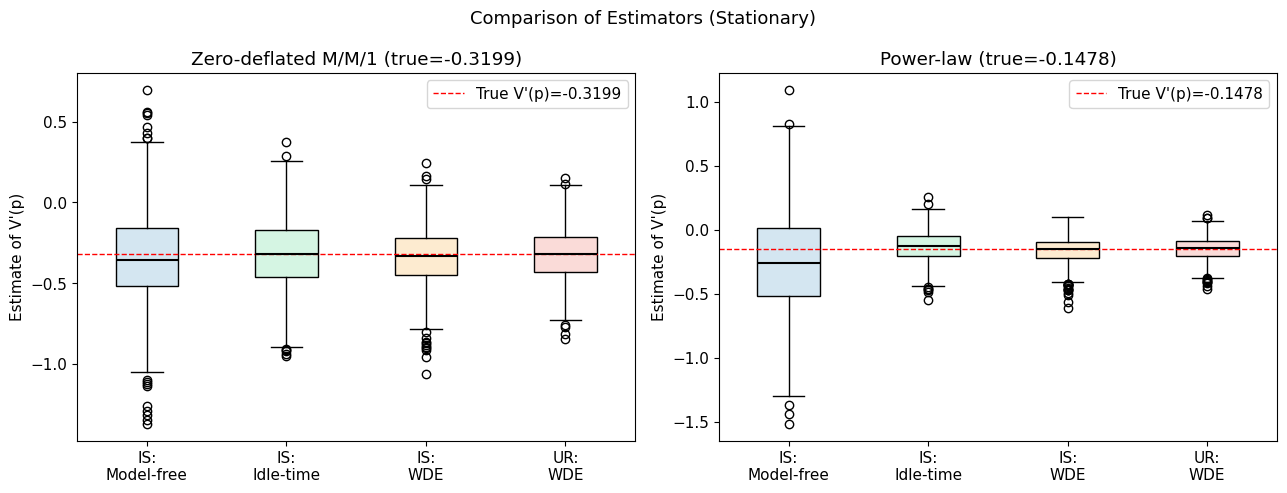

In [11]:
# --- Visualization: boxplots ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, results, title, true_val in [
    (axes[0], results_zi, f'Zero-deflated M/M/1 (true={true_Vprime_zi:.4f})', true_Vprime_zi),
    (axes[1], results_pl, f'Power-law (true={true_Vprime_pl:.4f})', true_Vprime_pl),
]:
    data = [results['IS_mf'], results['IS_it'],
            results['IS_wde'], results['UR_wde']]
    labels = ['IS:\nModel-free', 'IS:\nIdle-time',
              'IS:\nWDE', 'UR:\nWDE']
    bp = ax.boxplot(data, labels=labels, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 1.5})
    colors = ['#d4e6f1', '#d5f5e3', '#fdebd0', '#fadbd8']
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
    if true_val is not None:
        ax.axhline(true_val, color='red', linestyle='--', linewidth=1, label=f"True V'(p)={true_val:.4f}")
        ax.legend()
    ax.set_title(title)
    ax.set_ylabel("Estimate of V'(p)")

plt.suptitle('Comparison of Estimators (Stationary)', fontsize=13)
plt.tight_layout()
plt.savefig('comparison_stationary.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Non-Stationary Environment

We add a sinusoidal time-varying component to the arrival rate and compare switchback vs. user-randomized designs, using the windowed WDE estimator for the non-stationary case.

In [12]:
def run_nonstationary_study(lambda_k, mu, p, zeta, T, K, n_reps,
                            true_Vprime, kernel_lengths, label=''):
    """Compare IS (model-free, idle-time with kernel=T) across interval
    lengths, and UR WDE across kernel lengths, in non-stationary settings."""
    results = {}

    # IS with different interval lengths: model-free, idle-time (kernel=T)
    il_values = [2, 5, 10, 15, 25, 50, 75, 100]
    for il in il_values:
        key_mf  = f'IS_mf_il{il}'
        key_it  = f'IS_it_il{il}'
        results[key_mf]  = []
        results[key_it]  = []
        for rep in range(n_reps):
            seed = rep * 1000 + 13
            log = simulate_interval_switchback(
                lambda_k, mu, p, zeta, T, il, K=K, seed=seed,
                time_varying=True
            )
            stats = compute_summary_stats(log)
            results[key_mf].append(model_free_estimator(stats))
            results[key_it].append(idle_time_estimator(stats))

    # UR WDE with finer kernel lengths
    for kl in kernel_lengths:
        key = f'UR_wde_kl{kl}'
        results[key] = []
        for rep in range(n_reps):
            seed = rep * 1000 + 13
            log = simulate_user_level(
                lambda_k, mu, p, zeta, T, K=K, seed=seed,
                time_varying=True
            )
            est = wde_estimator_nonstationary_user_level(log, kernel_length=kl)
            results[key].append(est)

    # Convert to arrays
    for k in results:
        results[k] = np.array(results[k])

    # Summary
    print(f'\n{"=" * 70}')
    print(f'  {label}  (T={T}, n_reps={n_reps}, true V\' = {true_Vprime:.4f})')
    print(f'{"=" * 70}')
    print(f'{"Design + Estimator":<35s} {"Mean":>8s} {"Bias":>8s} {"Std":>8s} {"RMSE":>8s}')
    print('-' * 70)

    # Report IS: model-free and idle-time only
    for il in il_values:
        for prefix, name in [('IS_mf_il', 'IS: MF'), ('IS_it_il', 'IS: IT')]:
            key = f'{prefix}{il}'
            vals = results[key]
            bias = np.mean(vals) - true_Vprime
            std_val = np.std(vals)
            rmse = np.sqrt(bias**2 + std_val**2)
            print(f'{name + " il=" + str(il):<35s} {np.mean(vals):>8.4f} {bias:>8.4f} {std_val:>8.4f} {rmse:>8.4f}')

    print()
    # Report UR WDE
    for kl in kernel_lengths:
        key = f'UR_wde_kl{kl}'
        vals = results[key]
        bias = np.mean(vals) - true_Vprime
        std_val = np.std(vals)
        rmse = np.sqrt(bias**2 + std_val**2)
        print(f'{"UR: WDE kl=" + str(kl):<35s} {np.mean(vals):>8.4f} {bias:>8.4f} {std_val:>8.4f} {rmse:>8.4f}')

    return results

In [13]:
# Non-stationary zero-deflated M/M/1 with sinusoidal modulation
# true V'(p) estimated via large-scale simulation (see proxy computation above)

results_ns = run_nonstationary_study(
    lambda_k=lambda_zi_nonstat, mu=1.0, p=p, zeta=zeta,
    T=2000, K=K_MAX, n_reps=1000, true_Vprime=true_Vprime_zi_ns,
    kernel_lengths=[15, 25, 50, 75, 100, 150, 200],
    label='Non-stationary zero-deflated M/M/1 (sinusoidal)'
)


  Non-stationary zero-deflated M/M/1 (sinusoidal)  (T=2000, n_reps=1000, true V' = -0.4103)
Design + Estimator                      Mean     Bias      Std     RMSE
----------------------------------------------------------------------
IS: MF il=2                          -0.4627  -0.0524   0.3631   0.3669
IS: IT il=2                          -0.1411   0.2692   0.2067   0.3394
IS: MF il=5                          -0.4616  -0.0513   0.3612   0.3649
IS: IT il=5                          -0.2075   0.2028   0.2425   0.3161
IS: MF il=10                         -0.4299  -0.0196   0.3707   0.3712
IS: IT il=10                         -0.2269   0.1834   0.2632   0.3208
IS: MF il=15                         -0.3962   0.0141   0.3857   0.3860
IS: IT il=15                         -0.2434   0.1669   0.2877   0.3325
IS: MF il=25                         -0.4133  -0.0030   0.4254   0.4254
IS: IT il=25                         -0.2891   0.1212   0.3549   0.3750
IS: MF il=50                         -0.3597

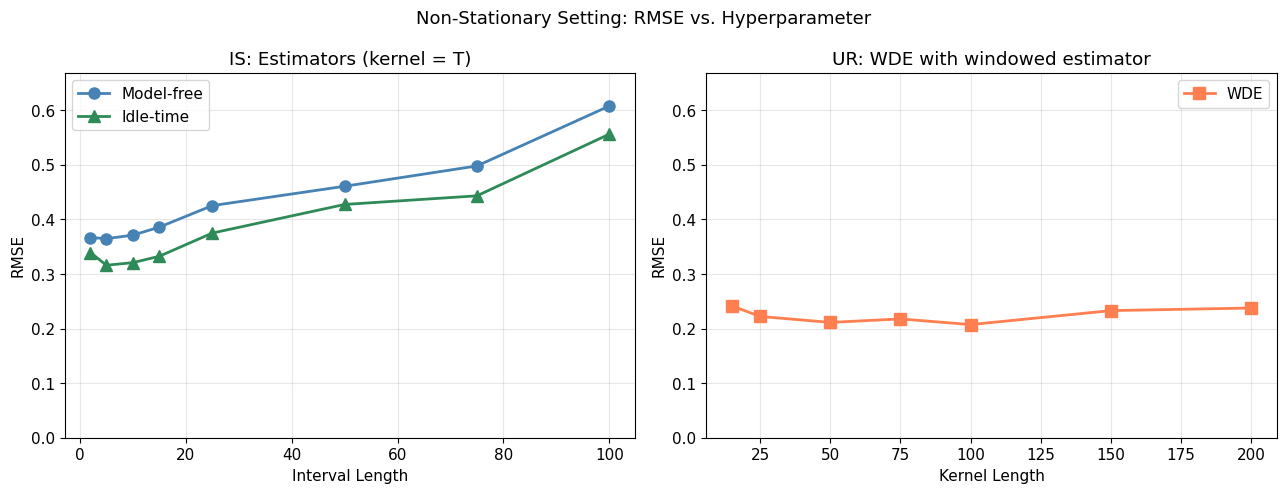

In [14]:
# --- Visualization: RMSE comparison ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: IS estimators (model-free, idle-time) vs interval length
il_values = [2, 5, 10, 15, 25, 50, 75, 100]

for est_name, prefix, color, marker in [
    ('Model-free', 'IS_mf_il', 'steelblue', 'o'),
    ('Idle-time',  'IS_it_il', 'seagreen', '^'),
]:
    rmse_vals = []
    for il in il_values:
        vals = results_ns[f'{prefix}{il}']
        bias = np.mean(vals) - true_Vprime_zi_ns
        rmse_vals.append(np.sqrt(bias**2 + np.var(vals)))
    axes[0].plot(il_values, rmse_vals, f'{marker}-', color=color,
                 linewidth=2, markersize=8, label=est_name)

axes[0].set_xlabel('Interval Length')
axes[0].set_ylabel('RMSE')
axes[0].set_title('IS: Estimators (kernel = T)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: UR WDE vs kernel length
kl_values = [15, 25, 50, 75, 100, 150, 200]
rmse_ur = []
for kl in kl_values:
    vals = results_ns[f'UR_wde_kl{kl}']
    bias = np.mean(vals) - true_Vprime_zi_ns
    rmse_ur.append(np.sqrt(bias**2 + np.var(vals)))

axes[1].plot(kl_values, rmse_ur, 's-', color='coral', linewidth=2, markersize=8, label='WDE')
axes[1].set_xlabel('Kernel Length')
axes[1].set_ylabel('RMSE')
axes[1].set_title('UR: WDE with windowed estimator')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Shared y-axis range
all_rmse = []
for prefix in ['IS_mf_il', 'IS_it_il']:
    for il in il_values:
        vals = results_ns[f'{prefix}{il}']
        bias = np.mean(vals) - true_Vprime_zi_ns
        all_rmse.append(np.sqrt(bias**2 + np.var(vals)))
all_rmse.extend(rmse_ur)
y_max = max(all_rmse) * 1.1
axes[0].set_ylim(0, y_max)
axes[1].set_ylim(0, y_max)

plt.suptitle('Non-Stationary Setting: RMSE vs. Hyperparameter', fontsize=13)
plt.tight_layout()
plt.savefig('comparison_nonstationary.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Variance Estimator Accuracy

We check that the plug-in variance estimators are well-calibrated by comparing their predictions to the empirical variance from repeated simulations.

In [15]:
# Collect variance estimates and compare to empirical variance
T_val = 2000
zeta_val = zeta

est_vars_mf  = []
est_vars_it  = []
est_vars_wde = []

for rep in range(1000):
    seed = rep * 1000 + 7
    log = simulate_interval_switchback(
        lambda_zi_mm1, mu=1.0, p=p, zeta=zeta_val,
        T=T_val, interval_length=100, K=K_MAX, seed=seed
    )
    s = compute_summary_stats(log)
    est_vars_mf.append(variance_model_free(s))
    est_vars_it.append(variance_idle_time(s))
    est_vars_wde.append(variance_wde(s))

# Empirical variance * T * zeta^2 gives the scaled variance
scale = T_val * zeta_val**2
emp_var_mf  = np.var(results_zi['IS_mf']) * scale
emp_var_it  = np.var(results_zi['IS_it']) * scale
emp_var_wde = np.var(results_zi['IS_wde']) * scale

print('Variance estimator calibration (zero-deflated M/M/1, T=2000):')
print(f'{"":<15s} {"Mean est":>10s} {"Empirical":>10s}')
print(f'{"Model-free":<15s} {np.mean(est_vars_mf):>10.4f} {emp_var_mf:>10.4f}')
print(f'{"Idle-time":<15s} {np.mean(est_vars_it):>10.4f} {emp_var_it:>10.4f}')
print(f'{"WDE":<15s} {np.mean(est_vars_wde):>10.4f} {emp_var_wde:>10.4f}')


Variance estimator calibration (zero-deflated M/M/1, T=2000):
                  Mean est  Empirical
Model-free          0.4178     0.4196
Idle-time           0.2611     0.2466
WDE                 0.1305     0.1513


### 3.4 Coverage of Confidence Intervals

In [16]:
# Check 95% CI coverage for zero-deflated M/M/1
true_val = true_Vprime_zi
coverage = {'mf': 0, 'it': 0, 'wde': 0}
n_reps_cov = 1000

for rep in range(n_reps_cov):
    seed = rep * 1000 + 7
    log = simulate_interval_switchback(
        lambda_zi_mm1, mu=1.0, p=p, zeta=zeta_val,
        T=T_val, interval_length=100, K=K_MAX, seed=seed
    )
    s = compute_summary_stats(log)

    for name, est_fn, var_fn in [
        ('mf',  model_free_estimator, variance_model_free),
        ('it',  idle_time_estimator,  variance_idle_time),
        ('wde', wde_estimator,        variance_wde),
    ]:
        est = est_fn(s)
        v = var_fn(s)
        lo, hi = confidence_interval(est, v, T_val, zeta_val, alpha=0.05)
        if lo <= true_val <= hi:
            coverage[name] += 1

print(f'95% CI coverage (zero-deflated M/M/1, T={T_val}, {n_reps_cov} reps):')
for name, label in [('mf', 'Model-free'), ('it', 'Idle-time'), ('wde', 'WDE')]:
    print(f'  {label:<15s}: {coverage[name]/n_reps_cov:.1%}')


95% CI coverage (zero-deflated M/M/1, T=2000, 1000 reps):
  Model-free     : 94.8%
  Idle-time      : 95.1%
  WDE            : 93.0%


---
## Summary

Key takeaways from the simulations:

1. **WDE dominates**: The weighted direct-effect estimator generally has the lowest variance.
2. **User-randomized (UR) helps**: The UR design with WDE achieves lower RMSE than switchback designs.
3. **Non-stationary robustness**: In non-stationary settings, user-randomized with windowed WDE is more robust to hyperparameter choices than interval switchbacks.
4. **Variance estimators are well-calibrated**: The plug-in variance formulae closely match empirical variances.